<a href="https://colab.research.google.com/github/pardeepkaur-cs/healthcare-anomaly-detection-ml/blob/main/healthcare_security_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Healthcare Cybersecurity ML Project

## Objective
This project aims to detect suspicious login behavior in healthcare systems using machine learning.

## Problem
Healthcare systems are vulnerable to insider threats and unauthorized access. Detecting abnormal login patterns is critical for protecting patient data.

## Approach
- Simulated hospital login dataset
- Feature engineering (login time, device, location, download size)
- Machine learning model (Decision Tree)
- Prediction of suspicious activity

## Tools Used
- Python
- Pandas
- Scikit-learn
- Google Colab

In [13]:
import pandas as pd

data = {
"user":["doctor1","doctor2","nurse1","doctor1","admin1","doctor2","nurse2","doctor1"],
"login_hour":[9,10,11,3,14,22,8,2],
"device":["hospital_pc","hospital_pc","tablet","unknown_device","hospital_pc","mobile","hospital_pc","unknown_device"],
"download_MB":[5,8,3,200,2,50,1,300],
"location":["hospital","hospital","hospital","unknown","hospital","home","hospital","unknown"]
}

df = pd.DataFrame(data)

df

,user,login_hour,device,download_MB,location
0,doctor1,9,hospital_pc,5,hospital
1,doctor2,10,hospital_pc,8,hospital
2,nurse1,11,tablet,3,hospital
3,doctor1,3,unknown_device,200,unknown
4,admin1,14,hospital_pc,2,hospital
5,doctor2,22,mobile,50,home
6,nurse2,8,hospital_pc,1,hospital
7,doctor1,2,unknown_device,300,unknown


## Data Labeling (Normal vs Suspicious)
We manually label suspicious behavior such as:
- login at unusual hours
- unknown device usage
- large data downloads

In [14]:
df["suspicious"] = [0,0,0,1,0,1,0,1]

df

,user,login_hour,device,download_MB,location,suspicious
0,doctor1,9,hospital_pc,5,hospital,0
1,doctor2,10,hospital_pc,8,hospital,0
2,nurse1,11,tablet,3,hospital,0
3,doctor1,3,unknown_device,200,unknown,1
4,admin1,14,hospital_pc,2,hospital,0
5,doctor2,22,mobile,50,home,1
6,nurse2,8,hospital_pc,1,hospital,0
7,doctor1,2,unknown_device,300,unknown,1


## Data Preprocessing
Convert categorical values into numerical format for machine learning

In [15]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df["device"] = encoder.fit_transform(df["device"])
df["location"] = encoder.fit_transform(df["location"])

df

,user,login_hour,device,download_MB,location,suspicious
0,doctor1,9,0,5,1,0
1,doctor2,10,0,8,1,0
2,nurse1,11,2,3,1,0
3,doctor1,3,3,200,2,1
4,admin1,14,0,2,1,0
5,doctor2,22,1,50,0,1
6,nurse2,8,0,1,1,0
7,doctor1,2,3,300,2,1


## Model Training
We train a Decision Tree model to classify suspicious behavior

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

X = df[["login_hour","device","download_MB","location"]]
y = df["suspicious"]

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

model = DecisionTreeClassifier()

model.fit(X_train,y_train)

print("Model trained successfully")

Model trained successfully


## Prediction Example
Test the model on a new login attempt

## Risk Scoring System
Instead of only classifying login attempts as normal or suspicious,
we assign a risk score based on multiple factors.

In [18]:
test_login = [[2,2,250,1]]

prediction = model.predict(test_login)

if prediction[0] == 1:
    print("⚠️ Suspicious Login Detected")
else:
    print("✅ Normal Login")

✅ Normal Login


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [20]:
def calculate_risk(login_hour, device, download_MB, location):

    risk = 0
    reasons = []

    # Rule 1: Unusual login time
    if login_hour < 6 or login_hour > 22:
        risk += 30
        reasons.append("Unusual login time")

    # Rule 2: High download
    if download_MB > 100:
        risk += 30
        reasons.append("High data download")

    # Rule 3: Unknown device
    if device == 2:   # encoded value (depends on earlier encoding)
        risk += 20
        reasons.append("Unknown device")

    # Rule 4: Unknown location
    if location == 1:
        risk += 20
        reasons.append("Unknown location")

    return risk, reasons

In [21]:
risk, reasons = calculate_risk(2,2,250,1)

print("Risk Score:", risk, "%")
print("Reasons:")
for r in reasons:
    print("-", r)

Risk Score: 100 %
Reasons:
- Unusual login time
- High data download
- Unknown device
- Unknown location


## Visualization of Login Behavior
We visualize login patterns to better understand suspicious activities.

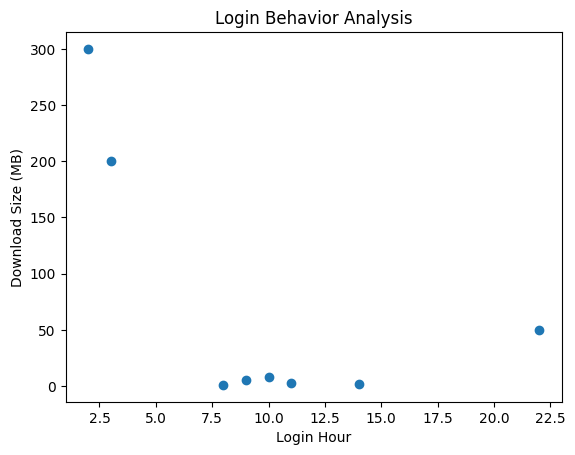

In [22]:
import matplotlib.pyplot as plt

# Plot login hour vs download size
plt.scatter(df["login_hour"], df["download_MB"])

plt.xlabel("Login Hour")
plt.ylabel("Download Size (MB)")
plt.title("Login Behavior Analysis")

plt.show()